## Homework 9
ELENE4730 Quantum Optimization and Machine Learning

Daniel Vitenko

In [1]:
from qiskit import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit.quantum_info import SparsePauliOp
from qiskit.visualization import plot_histogram
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
ibmsampler = Sampler(mode=backend)

qiskit_runtime_service.__init__:WARNING:2026-04-13 18:23:25,421: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-13 18:23:26,096: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-13 18:23:28,213: Using instance: open-instance, plan: open


# Problem 1

Final FD energy:            -14.99941439565796
Final Param-Shift energy:   -14.999414395660901
Final SPSA energy:          -13.39723909880145
Final Natural Grad energy:  -14.99999996837975


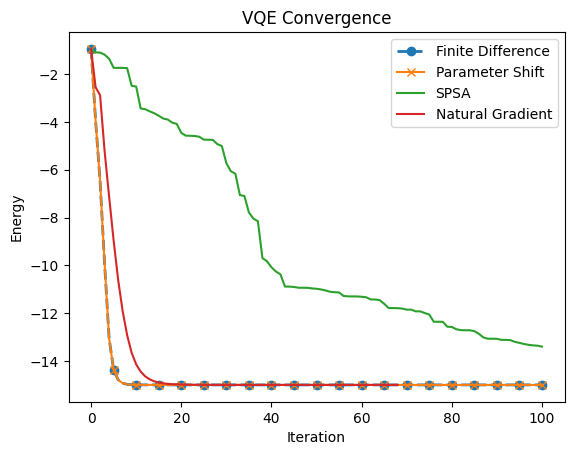

In [ ]:
from qiskit.circuit.library import EfficientSU2
from qiskit_algorithms.gradients import ParamShiftEstimatorGradient, LinCombQGT
from qiskit_algorithms.optimizers import SPSA

H = SparsePauliOp(
    ["ZIZI", "IZIZ", "IZZI", "ZIII", "IIIZ"],
    coeffs=[3, -5, -2, 4, -1]
)

num_qubits = H.num_qubits
ansatz = EfficientSU2(
    num_qubits=num_qubits,
    reps=2,
    entanglement="linear"
)

num_params = ansatz.num_parameters
estimator = StatevectorEstimator()

def energy(theta):
    pub = (ansatz, [H], [theta])
    result = estimator.run([pub]).result()
    return result[0].data.evs[0]

# finite difference gradient
def finite_diff_grad(theta, h=1e-5):
    grad = np.zeros_like(theta)
    for i in range(len(theta)):
        shift = np.zeros_like(theta)
        shift[i] = h
        grad[i] = (energy(theta + shift) - energy(theta - shift)) / (2 * h)
    return grad


def train_fd(theta0, lr=0.1, maxiter=100, tol=1e-8):
    theta = theta0.copy()
    energies = []
    step = 0

    while True:
        e = energy(theta)
        energies.append(e)

        grad = finite_diff_grad(theta)
        theta = theta - lr * grad

        if (step > 0 and abs(energies[-1] - energies[-2]) < tol) or (step >= maxiter):
            break

        step += 1

    return theta, energies

# analytic gradient via parameter-shift
param_shift = ParamShiftEstimatorGradient(estimator)

def analytic_grad(theta):
    result = param_shift.run(
        [ansatz],
        [H], 
        [theta],
        [list(ansatz.parameters)]
    ).result()
    return np.array(result.gradients[0], dtype=float)


def train_param_shift(theta0, lr=0.1, maxiter=100, tol=1e-8):
    theta = theta0.copy()
    energies = []
    step = 0

    while True:
        e = energy(theta)
        energies.append(e)

        grad = analytic_grad(theta)
        theta = theta - lr * grad

        if (step > 0 and abs(energies[-1] - energies[-2]) < tol) or (step >= maxiter):
            break

        step += 1

    return theta, energies

# SPSA
def train_spsa(theta0, lr=0.01, eps=0.1, maxiter=100, tol=1e-8):
    theta = theta0.copy()
    energies = []
    step = 0

    while True:
        e = energy(theta)
        energies.append(e)

        delta = np.random.choice([-1, 1], size=len(theta))

        theta_plus = theta + eps * delta
        theta_minus = theta - eps * delta

        e_plus = energy(theta_plus)
        e_minus = energy(theta_minus)

        grad = (e_plus - e_minus) / (2 * eps * delta)

        theta = theta - lr * grad

        if (step > 0 and abs(energies[-1] - energies[-2]) < tol) or (step >= maxiter):
            break

        step += 1

    return theta, energies

# natural gradient
qgt = LinCombQGT(estimator)

def natural_grad_step(theta, lr=0.1, reg=1e-6):
    grad = analytic_grad(theta)

    qgt_result = qgt.run(
        [ansatz],
        [theta],  
        [list(ansatz.parameters)] 
    ).result()

    G = np.array(qgt_result.qgts[0], dtype=float)
    G = G + reg * np.eye(len(theta))

    nat_grad = np.linalg.solve(G, grad)
    new_theta = theta - lr * nat_grad
    return new_theta 


def train_natural(theta0, lr=0.1, maxiter=100, tol=1e-8):
    theta = theta0.copy()
    energies = []
    step = 0

    while True:
        e = energy(theta)
        energies.append(e)

        theta = natural_grad_step(theta, lr=lr)

        if (step > 0 and abs(energies[-1] - energies[-2]) < tol) or (step >= maxiter):
            break

        step += 1

    return theta, energies

np.random.seed(42)
theta0 = 2 * np.pi * np.random.rand(num_params)

theta_fd, E_fd = train_fd(theta0, lr=0.1, maxiter=100)
theta_ps, E_ps = train_param_shift(theta0, lr=0.1, maxiter=100)
theta_spsa, E_spsa = train_spsa(theta0, lr=0.01, eps=0.1, maxiter=100)
theta_ng, E_ng = train_natural(theta0, lr=0.01, maxiter=100)

print("Final FD energy:           ", E_fd[-1])
print("Final Param-Shift energy:  ", E_ps[-1])
print("Final SPSA energy:         ", E_spsa[-1])
print("Final Natural Grad energy: ", E_ng[-1])

plt.plot(E_fd, '--', marker='o', markevery=5, linewidth=2, label="Finite Difference")
plt.plot(E_ps, '-', marker='x', markevery=5, label="Parameter Shift")
plt.plot(E_spsa, label="SPSA")
plt.plot(E_ng, label="Natural Gradient")
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("VQE Convergence")
plt.legend()
plt.show()

(Note: The convergence curve for finite difference is almost exactly overlapped by the parameter shift curve.) 

# Problem 2

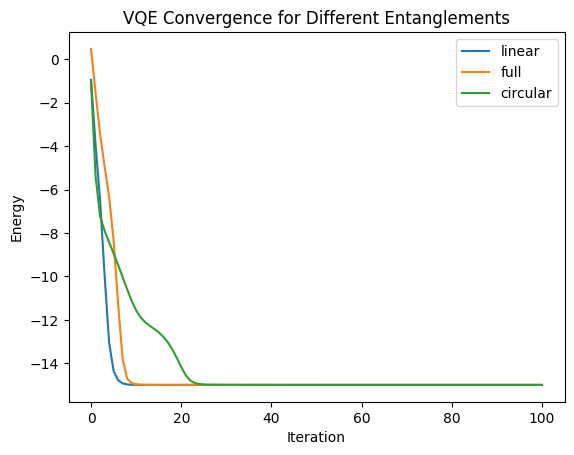


Entanglement: linear
Final energy: -14.999414395660901
Most likely state: 1000


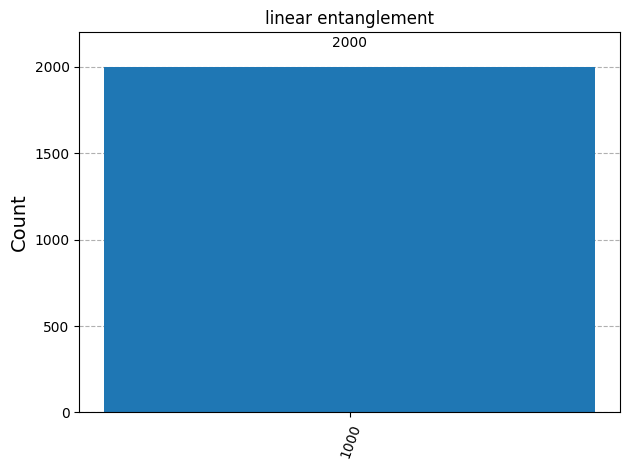


Entanglement: full
Final energy: -14.999943501787538
Most likely state: 1000


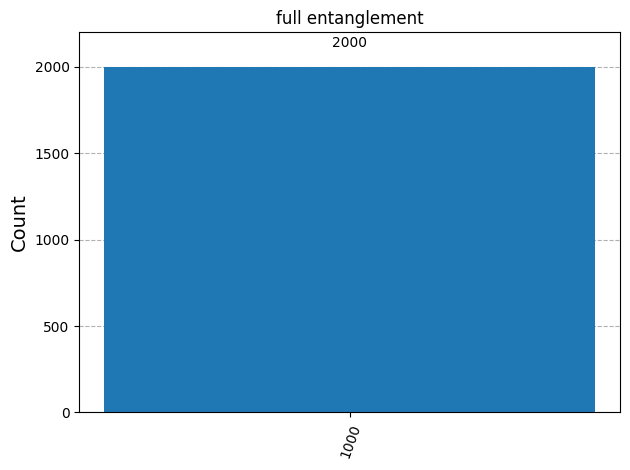


Entanglement: circular
Final energy: -14.999993345461471
Most likely state: 1000


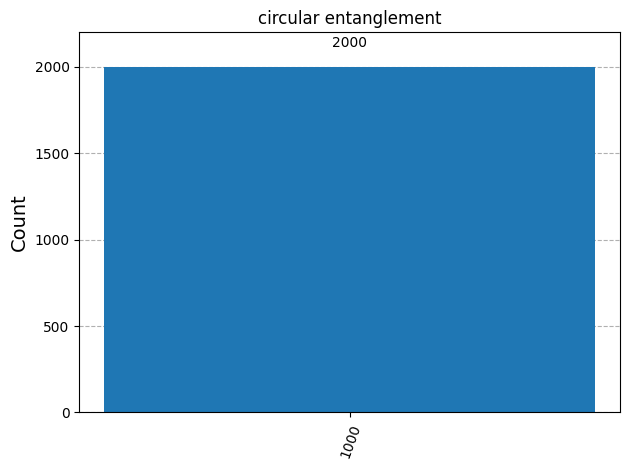

In [3]:
sampler = StatevectorSampler()
estimator = StatevectorEstimator()
param_shift = ParamShiftEstimatorGradient(estimator)

def analytic_grad(ansatz, theta):
    result = param_shift.run(
        [ansatz],
        [H], 
        [theta],
        [list(ansatz.parameters)]
    ).result()
    return np.array(result.gradients[0], dtype=float)


def train_param_shift(ansatz, theta0, lr=0.1, maxiter=100, tol=1e-8):
    theta = theta0.copy()
    energies = []
    step = 0

    while True:
        e = energy(theta)
        energies.append(e)

        grad = analytic_grad(ansatz, theta)
        theta = theta - lr * grad

        if (step > 0 and abs(energies[-1] - energies[-2]) < tol) or (step >= maxiter):
            break

        step += 1

    return theta, energies

def get_counts(ansatz, theta, shots=2000):
    qc = ansatz.assign_parameters(theta)
    qc = qc.copy()
    qc.measure_all()

    job = sampler.run([(qc,)], shots=shots)
    result = job.result()
    
    data_obj = result[0].data
    first_key = list(data_obj.keys())[0]
    counts = getattr(data_obj, first_key).get_counts()
    return counts

entanglements = ["linear", "full", "circular"]

results = {}

for ent in entanglements:
    ansatz = EfficientSU2(
        num_qubits=H.num_qubits,
        reps=2,
        entanglement=ent
    )

    np.random.seed(42)
    theta0 = 2 * np.pi * np.random.rand(ansatz.num_parameters)

    theta_opt, energies = train_param_shift(ansatz, theta0, lr=0.1, maxiter=100)
    counts = get_counts(ansatz, theta_opt, shots=2000)

    best_state = max(counts, key=counts.get)

    results[ent] = {
        "ansatz": ansatz,
        "theta": theta_opt,
        "energies": energies,
        "counts": counts,
        "best_state": best_state,
        "final_energy": energies[-1]
    }

for ent in entanglements:
    plt.plot(results[ent]["energies"], label=ent)

plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("VQE Convergence for Different Entanglements")
plt.legend()
plt.show()

for ent in entanglements:
    print(f"\nEntanglement: {ent}")
    print("Final energy:", results[ent]["final_energy"])
    print("Most likely state:", results[ent]["best_state"])

    plot_histogram(results[ent]["counts"], title=f"{ent} entanglement")
    plt.show()

# Problem 3

Best full energy: -3.7664404915109726
Optimal parameters: [-1.56620471  4.94061601 -3.11406422 -1.39768216  6.42899176 -4.19520221
 -1.22231019 -6.27903438 -0.97411539 -6.10662651  3.1607256  -4.58090919
 -7.88131788 -3.15763023 -0.50870936  1.00585714  6.41938035 -4.77438107
 -0.02171957  3.00406082  0.66737434 -7.52421002  7.52646166 -5.29557608]


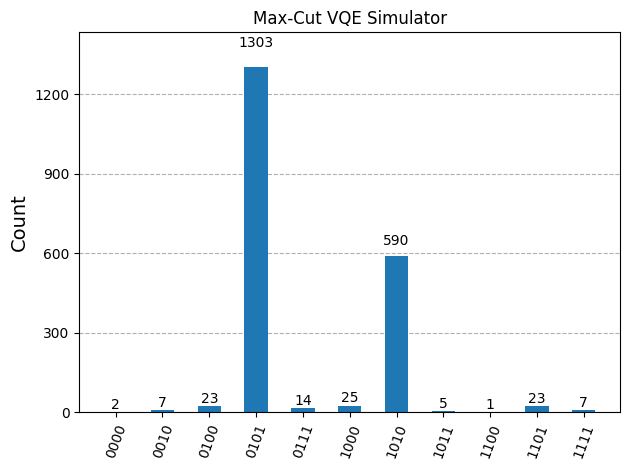

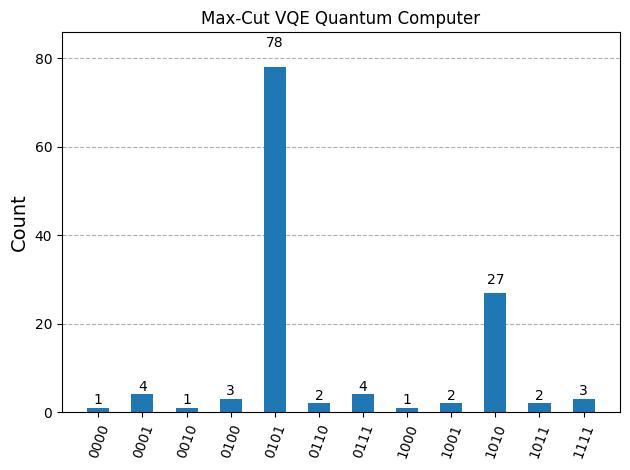

In [4]:
# square graph
n = 4
edges = [(0, 1), (1, 2), (2, 3), (3, 0)]

paulis = []
for i, j in edges:
    z = ['I'] * n
    z[i] = 'Z'
    z[j] = 'Z'
    paulis.append(("".join(z), 1.0))

H = SparsePauliOp.from_list(paulis)

ansatz = EfficientSU2(
    num_qubits=n,
    reps=2,
    entanglement="linear"
)

estimator = StatevectorEstimator()
optimizer = SPSA(maxiter=200)

vqe = VQE(estimator, ansatz, optimizer)
result = vqe.compute_minimum_eigenvalue(H)

print("Best full energy:", result.eigenvalue.real)
print("Optimal parameters:", result.optimal_point)

# Simulator
sampler = StatevectorSampler()

qc = ansatz.assign_parameters(result.optimal_point)
qc.measure_all()

job = sampler.run([qc], shots=2000)
samp_result = job.result()

data_obj = samp_result[0].data
first_key = list(data_obj.keys())[0]
counts = getattr(data_obj, first_key).get_counts()

plot_histogram(counts, title="Max-Cut VQE Simulator")
plt.show()

# IBM Quantum Computer
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
counts = result[0].data.meas.get_counts()
plot_histogram(counts, title="Max-Cut VQE Quantum Computer");


Previous histograms on the same graph gave approximately even probabilities to 0101 and 1010 every run, while VQE is more biased toward one or the other in each subsequent run. Each run shifts more probability to 0101 or 1010, but the interesting part is that the simulator and quantum computer give approximately the same distribution each run.

# Problem 4

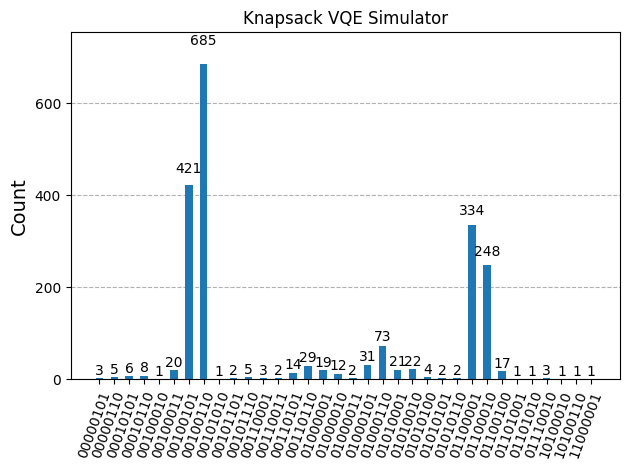

Simulator results:
Best state:  [0 1 1 1]
Best value:  21


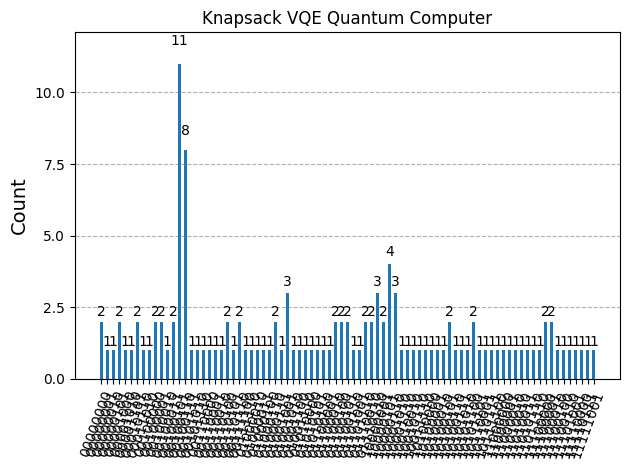

Quantum Computer results:
Best state:  [0 1 1 1]
Best value:  21


In [5]:
items = [
    {"value": 8, "weight": 4},
    {"value": 11, "weight": 5},
    {"value": 6, "weight": 3},
    {"value": 4, "weight": 2}
]
cap = 10
n = len(items)

qp = QuadraticProgram()
for i in range(n):
    qp.binary_var(f"x{i}")
qp.maximize(linear={f"x{i}": items[i]["value"] for i in range(n)})
qp.linear_constraint({f"x{i}": items[i]["weight"] for i in range(n)}, "<=", cap)

# QuadraticProgram -> QUBO -> Ising
converter  = QuadraticProgramToQubo()
qubo       = converter.convert(qp)
qubo_op, _ = qubo.to_ising()
num_qubits = qubo.get_num_vars()

# VQE
ansatz = TwoLocal(num_qubits, ["ry", "rz"], "cx", entanglement="full", reps=3)
vqe = VQE(
    estimator=StatevectorEstimator(),
    ansatz=ansatz,
    optimizer=COBYLA(maxiter=1000),
    initial_point=np.random.default_rng(42).uniform(0, 2*np.pi, ansatz.num_parameters),
)
result = vqe.compute_minimum_eigenvalue(qubo_op)

# extract best solution from counts
def best_from_counts(counts):
    best_val, best_x = -1, None
    for state, _ in sorted(counts.items(), key=lambda x: x[1], reverse=True):
        x_qubo = np.array([int(b) for b in state[::-1]])
        x_orig = converter.interpret(x_qubo)[:n].astype(int)
        w = int(sum(x_orig[i] * items[i]["weight"] for i in range(n)))
        v = int(sum(x_orig[i] * items[i]["value"]  for i in range(n)))
        if w <= cap and v > best_val:
            best_val, best_x = v, x_orig
    print("Best state: ", best_x)
    print("Best value: ", best_val)

# Simulator
sampler = StatevectorSampler()

qc = ansatz.assign_parameters(result.optimal_point)
qc.measure_all()
job = sampler.run([qc], shots=2000)
samp_result = job.result()

data_obj = samp_result[0].data
first_key = list(data_obj.keys())[0]
counts = getattr(data_obj, first_key).get_counts()

plot_histogram(counts, title="Knapsack VQE Simulator")
plt.show()
print("Simulator results:")
best_from_counts(counts)

# IBM Quantum Computer
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

job = ibmsampler.run([isa_circuit], shots=128)

result = job.result()
ibm_counts = result[0].data.meas.get_counts()
plot_histogram(ibm_counts, title="Knapsack VQE Quantum Computer");
plt.show()
print("Quantum Computer results:")
best_from_counts(ibm_counts)



These results are accurate and match the results from the previous homeworks.